In [1]:
# IMPORTS
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Module imports
from prp.task_generator import generate_task_patterns, generate_fixed_task_set
from prp.nn_wrapper import TaskNetworkWrapper
from prp.prp_simulator import sweep_soa, run_prp_trial
from prp.training_utils import train_with_optional_multitask, train_with_control_config 
from prp.threshold_utils import optimize_lca_threshold, choose_onset_policy, optimize_reward_rate_threshold


# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


In [2]:
# Reload module when making live edits
import importlib
import prp.prp_simulator as prp_simulator
importlib.reload(prp_simulator)

<module 'prp.prp_simulator' from '/home/acesmeci/Code/prp_model/prp/prp_simulator.py'>

In [2]:
# New model loading cell
from prp.nn_wrapper import TaskNetworkWrapper
import torch

# Match exactly what you used in scripts/train_model.py:
wrapper = TaskNetworkWrapper(
    stim_input_dim = 3 * 3,    # N_pathways * N_features
    task_input_dim = 3 ** 2,   # N_pathways^2
    hidden_dim     = 100,
    output_dim     = 3 * 3,
    learning_rate  = 0.3,
    device         = "cpu"
)

# Now load
#wrapper.model.load_state_dict(torch.load("../output/trained_models/trained_model.pth"))
#wrapper.model.eval()
print("✅ Loaded model, ready for inference.")

✅ Loaded model, ready for inference.


### New training (MATLAB-style)

In [3]:
import torch
from prp.nn_wrapper import TaskNetworkWrapper
from prp.training_set import generate_training_set_matlab_style  # or wherever you placed it

# 1) Build exhaustive, noise-free, same across tasks
X, T, Y, _ = generate_training_set_matlab_style()

# 2) Train
wrapper = TaskNetworkWrapper(
    stim_input_dim=9, task_input_dim=9, hidden_dim=100, output_dim=9,
    learning_rate=0.3, device="cpu"
)
wrapper.train_online(
    torch.tensor(X), torch.tensor(T), torch.tensor(Y),
    max_epochs=3000, stop_loss=1e-3, print_every=50
)

torch.save(wrapper.model.state_dict(), "../output/trained_models/trained_model_init01_all.pth")
print("✅ Model saved to output/trained_model_init005.pth")

# 3) Check Pearson AD/BE on task→hidden (same code you already have)
# Expectation: AD/BE should jump noticeably vs. the random/noisy regime.


Epoch 0000 | Loss: 0.0984 | Acc: 0.096
Epoch 0050 | Loss: 0.0748 | Acc: 0.578
Epoch 0100 | Loss: 0.0528 | Acc: 0.659
Epoch 0150 | Loss: 0.0426 | Acc: 0.681
Epoch 0200 | Loss: 0.0347 | Acc: 0.778
Epoch 0250 | Loss: 0.0304 | Acc: 0.948
Epoch 0300 | Loss: 0.0209 | Acc: 1.000
Epoch 0350 | Loss: 0.0105 | Acc: 1.000
Epoch 0400 | Loss: 0.0055 | Acc: 1.000
Epoch 0450 | Loss: 0.0034 | Acc: 1.000
Epoch 0500 | Loss: 0.0024 | Acc: 1.000
Epoch 0550 | Loss: 0.0019 | Acc: 1.000
Epoch 0600 | Loss: 0.0015 | Acc: 1.000
Epoch 0650 | Loss: 0.0013 | Acc: 1.000
Epoch 0700 | Loss: 0.0011 | Acc: 1.000
✅ Converged at epoch 0731 | Loss: 0.0010
✅ Model saved to output/trained_model_init005.pth


In [4]:
wrapper.model.eval()

TaskNetwork(
  (fc_input_hidden): Linear(in_features=9, out_features=100, bias=False)
  (fc_task_hidden): Linear(in_features=9, out_features=100, bias=False)
  (fc_hidden_output): Linear(in_features=100, out_features=9, bias=False)
  (fc_task_output): Linear(in_features=9, out_features=9, bias=False)
  (act): Sigmoid()
)

### Init-fixed training

In [2]:
# Construct the wrapper
from prp.nn_wrapper import TaskNetworkWrapper

wrapper = TaskNetworkWrapper(
    stim_input_dim = 3*3,
    task_input_dim = 3**2,
    hidden_dim     = 100,
    output_dim     = 3*3,
    learning_rate  = 0.3,
    # Sim-3 init/bias/decay:
    init_scale=0.1,
    init_task_scale=None,   # → 0.1, same as MATLAB for Sim-3
    bias_offset=-2.0,
    default_weight_decay=0.0,  # Sim-3 uses no L2
    device="cpu",
)
print("✅ Model constructed.")


✅ Model constructed.


In [3]:
# Generate training set & train
import torch
from prp.training_set import generate_training_set_matlab_style

# 1) Exhaustive, noise-free, same across tasks (A,B,D,E,C)
X, T, Y, _ = generate_training_set_matlab_style()

# 2) Train
wrapper.train_online(
    torch.tensor(X), torch.tensor(T), torch.tensor(Y),
    max_epochs=5000, stop_loss=1e-3, print_every=50
)

# 3) Save
torch.save(wrapper.model.state_dict(), "../output/trained_models/trained_model_sim3_init01.pth")
print("✅ Saved.")


/home/acesmeci/code/prp_model/prp/nn_wrapper.py:105: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)


Epoch 0000 | Loss: 0.0986 | Acc: 0.178
Epoch 0050 | Loss: 0.0745 | Acc: 0.585
Epoch 0100 | Loss: 0.0526 | Acc: 0.674
Epoch 0150 | Loss: 0.0420 | Acc: 0.726
Epoch 0200 | Loss: 0.0346 | Acc: 0.711
Epoch 0250 | Loss: 0.0316 | Acc: 0.830
Epoch 0300 | Loss: 0.0258 | Acc: 0.963
Epoch 0350 | Loss: 0.0150 | Acc: 1.000
Epoch 0400 | Loss: 0.0072 | Acc: 1.000
Epoch 0450 | Loss: 0.0039 | Acc: 1.000
Epoch 0500 | Loss: 0.0026 | Acc: 1.000
Epoch 0550 | Loss: 0.0019 | Acc: 1.000
Epoch 0600 | Loss: 0.0015 | Acc: 1.000
Epoch 0650 | Loss: 0.0012 | Acc: 1.000
Epoch 0700 | Loss: 0.0010 | Acc: 1.000
✅ Converged at epoch 0713 | Loss: 0.0010
✅ Saved.


In [4]:
with torch.no_grad():
    means, S = wrapper.model.task_similarity_hidden(
        torch.tensor(X), torch.tensor(T)
    )
print(S)


[[ 1.          0.9290429          nan -0.18653127 -0.19278266         nan
          nan         nan  0.3358791 ]
 [ 0.9290429   1.                 nan -0.18635417 -0.1096026          nan
          nan         nan  0.37052222]
 [        nan         nan         nan         nan         nan         nan
          nan         nan         nan]
 [-0.18653127 -0.18635417         nan  1.          0.93764544         nan
          nan         nan  0.40007476]
 [-0.19278266 -0.1096026          nan  0.93764544  1.                 nan
          nan         nan  0.43169301]
 [        nan         nan         nan         nan         nan         nan
          nan         nan         nan]
 [        nan         nan         nan         nan         nan         nan
          nan         nan         nan]
 [        nan         nan         nan         nan         nan         nan
          nan         nan         nan]
 [ 0.3358791   0.37052222         nan  0.40007476  0.43169301         nan
          nan         

/home/acesmeci/code/prp_model/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/acesmeci/code/prp_model/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Compute Fixed Task-2 Threshold

In [7]:
# === Notebook cell: compute fixed Task-B threshold ===

import numpy as np
import torch
from prp.task_generator   import generate_fixed_task_set
from prp.threshold_utils  import optimize_lca_threshold_dist
from prp.lca              import run_lca_avg

# 1) Get a batch of Task B examples
inp, tasks_sgl, train_sgl, meta = generate_fixed_task_set(seed=SEED)
mask_B = (meta["task_indices"] == "B")
input_B  = inp[mask_B]
task_B   = tasks_sgl[mask_B]

# 2) Pick one representative trial (or average across several)
input_b = input_B[0]
task_b  = task_B[0]

# 3) Run the network with no carry-over (pure single-task B)
output_series_th = wrapper.integrate(
    torch.from_numpy(input_b[None,:]).float(),
    torch.from_numpy(task_b[None,:]).float(),
    persistence=0.0
)
output_np = np.stack([o.numpy() for o in output_series_th], axis=0)

# 4) Decode which output indices correspond to B
N_pathways, N_features = 3, 3
mat_B = task_b.reshape(N_pathways, N_pathways).T
in_B, out_B = np.argwhere(mat_B==1)[0]
idxs_b = list(range(out_B*N_features, (out_B+1)*N_features))
correct_b = np.argmax(input_b[in_B*N_features:(in_B+1)*N_features])

# 5) Fit LCA threshold once
thresholds = np.arange(0.0, 1.6, 0.1)
z_B, rr_B = optimize_lca_threshold_dist(
    output_np, idxs_b, correct_response_idx=correct_b,
    thresholds=thresholds, ITI=0.5, n_repeats=100
)
print("Fixed Task B threshold =", z_B)

Fixed Task B threshold = 0.5


/home/acesmeci/code/prp_model/prp/lca.py:279: RuntimeWarning: Mean of empty slice
  rts  = np.nanmean(all_rts,  axis=1)                   # [n_thresholds]


In [8]:
import numpy as np, torch
from prp.task_generator import generate_fixed_task_set
from prp.threshold_utils import optimize_lca_threshold_dist

def _decode_task(task_vec, input_vec, N_pathways=3, N_features=3):
    M = task_vec.reshape(N_pathways, N_pathways)   # row-major (NO transpose)
    i_in, i_out = np.argwhere(M == 1)[0]
    correct = np.argmax(input_vec[i_in*N_features:(i_in+1)*N_features])
    idxs = list(range(i_out*N_features, (i_out+1)*N_features))
    return idxs, correct

def compute_fixed_threshold_for_task(
    wrapper,
    task_name="A",
    K=20,
    thresholds=np.arange(0.1, 1.6, 0.1),
    ITI=0.5,
    n_repeats=100,
    persistence=0.0,
    seed=42
):
    inp, tasks_sgl, _, meta = generate_fixed_task_set(seed=seed)
    mask = (meta["task_indices"] == task_name)
    X, T = inp[mask], tasks_sgl[mask]

    rng = np.random.RandomState(seed)
    pick = rng.choice(len(X), size=min(K, len(X)), replace=False)

    z_list, rr_list = [], []
    for k in pick:
        x = torch.from_numpy(X[k][None, :]).float()
        t = torch.from_numpy(T[k][None, :]).float()

        out_th = wrapper.integrate(x, t, persistence=persistence)
        out_np = np.stack([o.numpy() for o in out_th], axis=0)

        rel_idxs, correct_idx = _decode_task(T[k], X[k])

        z_star, res = optimize_lca_threshold_dist(
            out_np, rel_idxs,
            correct_response_idx=correct_idx,
            thresholds=thresholds, ITI=ITI, n_repeats=n_repeats
        )
        z_list.append(float(z_star))
        # best RR at the chosen z
        best_i = int(np.argmax(res["reward_rates"]))
        rr_list.append(float(res["reward_rates"][best_i]))

    z_med = float(np.median(z_list))
    print("z estimates:", np.round(z_list, 3))
    print("RR at best z:", np.round(rr_list, 3))
    print(f"Selected fixed z_{task_name} (median): {z_med:.3f}")
    return z_med

# Example:
z_A = compute_fixed_threshold_for_task(
    wrapper, task_name="A", K=20, ITI=0.5, n_repeats=150,
    thresholds=np.arange(0.1, 1.05, 0.05)   # avoids huge z that never fire
)


z estimates: [0.65 0.5  0.5  0.45 0.45 0.6  0.4  0.6  0.45 0.4  0.6  0.5  0.4  0.55
 0.45 0.55 0.6  0.4  0.4  0.55]
RR at best z: [1.477 1.528 1.538 1.538 1.518 1.446 1.518 1.528 1.528 1.518 1.477 1.518
 1.036 1.528 1.528 1.497 1.497 1.497 1.508 1.528]
Selected fixed z_A (median): 0.500


### PRP Simulation

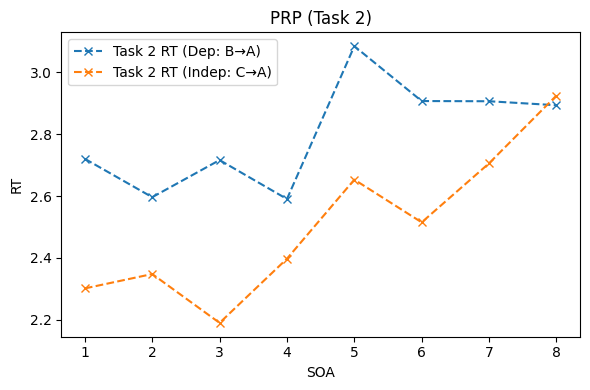

In [9]:
# PRP Simulator. Takes ~2 minutes to run with 10 trials per SOA.
# ~5 minutes with 50 trials per SOA.

def generate_trial_pair(prp_pair=("B","A"), N_pathways=3, N_features=3, seed=None):
    task_map = {'A': (0,0), 'B': (1,1), 'C': (2,2), 'D': (0,1), 'E': (1,0)}
    rng = np.random.RandomState(seed)

    def sample_single_task(task_name, shared_features=None):
        in_dim, out_dim = task_map[task_name]
        feats = shared_features if shared_features is not None \
                else rng.randint(0, N_features, size=N_pathways)

        stim = np.zeros(N_pathways*N_features, dtype=np.float32)
        for i in range(N_pathways):
            stim[i*N_features + feats[i]] = 1

        cue = np.zeros(N_pathways**2, dtype=np.float32)
        cue[in_dim*N_pathways + out_dim] = 1
        return stim, cue

    # (optional) use the SAME stimulus features for both tasks:
    feats = np.random.randint(0, N_features, size=N_pathways)
    stim1, cue1 = sample_single_task(prp_pair[0], shared_features=feats)
    stim2, cue2 = sample_single_task(prp_pair[1], shared_features=feats)
    return stim1, stim2, cue1, cue2


# ✅ Optional test calls
_ = generate_trial_pair(prp_pair=("B", "A"))
_ = generate_trial_pair(prp_pair=("C", "A"))


# Dependent B→A vs Independent C→A
gen_dep = lambda: generate_trial_pair(("B","A"))
gen_ind = lambda: generate_trial_pair(("C","A"))

# IMPORTANT: compute a single fixed threshold for Task-2=A in single-task mode
# (rename your z_B to z_A if you're using A as Task-2 in both conditions)

results_ba = sweep_soa(wrapper, gen_dep, list(range(1,9)),
                       n_trials_per_soa=30, persistence=0.90,
                       z_task2_fixed=z_A, optimize_onset=False)

results_ca = sweep_soa(wrapper, gen_ind, list(range(1,9)),
                       n_trials_per_soa=30, persistence=0.90,
                       z_task2_fixed=z_A, optimize_onset=False)

plt.figure(figsize=(6,4))
plt.plot(results_ba["soa"], results_ba["rt_task2"], "x--", label="Task 2 RT (Dep: B→A)")
plt.plot(results_ca["soa"], results_ca["rt_task2"], "x--", label="Task 2 RT (Indep: C→A)")
plt.xlabel("SOA"); plt.ylabel("RT"); plt.title("PRP (Task 2)")
plt.legend(); plt.tight_layout(); plt.show()


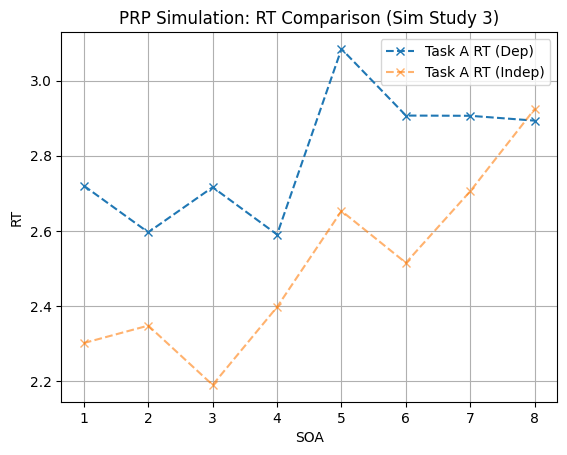

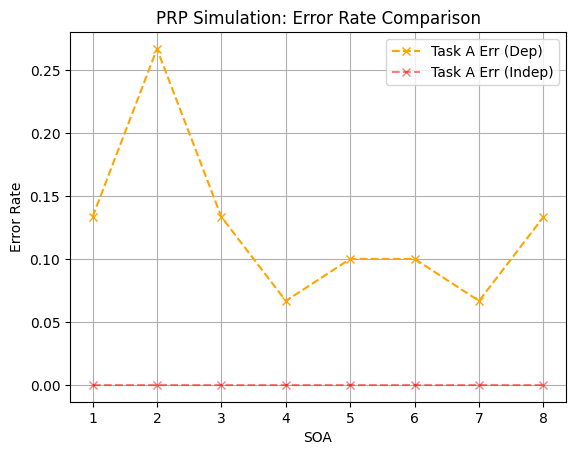

In [11]:
# Plot RTs and Error Rates

# RTs
#plt.plot(results_ba["soa"], results_ba["rt_b"], label="Task B RT (Dep)", marker='o')
plt.plot(results_ba["soa"], results_ba["rt_task2"], label="Task A RT (Dep)", marker='x', linestyle='--')

#plt.plot(results_ca["soa"], results_ca["rt_b"], label="Task C RT (Indep)", marker='o', alpha=0.6)
plt.plot(results_ca["soa"], results_ca["rt_task2"], label="Task A RT (Indep)", marker='x', linestyle='--', alpha=0.6)

plt.xlabel("SOA")
plt.ylabel("RT")
plt.title("PRP Simulation: RT Comparison (Sim Study 3)")
plt.grid(True)
plt.legend()
plt.savefig("../output/plots/onset_policy/RT_p090_zb05_nt30_ITI05_init01.png", dpi=300)
plt.show()

# Error Rates
err_a_ba = [1 - a if not np.isnan(a) else np.nan for a in results_ba["acc_task2"]]
err_b_ba = [1 - b if not np.isnan(b) else np.nan for b in results_ba["acc_task1"]]
err_a_ca = [1 - a if not np.isnan(a) else np.nan for a in results_ca["acc_task2"]]
err_c_ca = [1 - b if not np.isnan(b) else np.nan for b in results_ca["acc_task1"]]

#plt.plot(results_ba["soa"], err_b_ba, marker='o', label="Task B Err (Dep)", color="cyan")
plt.plot(results_ba["soa"], err_a_ba, marker='x', linestyle='--', label="Task A Err (Dep)", color="orange")

#plt.plot(results_ca["soa"], err_c_ca, marker='o', label="Task C Err (Indep)", color="darkblue", alpha=0.5)
plt.plot(results_ca["soa"], err_a_ca, marker='x', linestyle='--', label="Task A Err (Indep)", color="red", alpha=0.5)

plt.xlabel("SOA")
plt.ylabel("Error Rate")
plt.title("PRP Simulation: Error Rate Comparison")
plt.grid(True)
plt.legend()
plt.savefig("../output/plots/onset_policy/ER_p090_zb05_nt30_ITI05_init01.png", dpi=300)
plt.show()

# Diagnostics

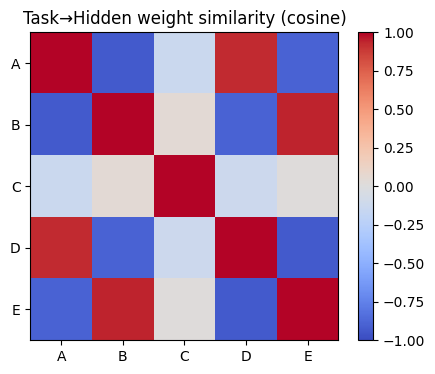

sim(A,D)= 0.9283897280693054
sim(B,E)= 0.9405571222305298
sim(A,B)= -0.9320817589759827


In [5]:
import numpy as np, torch
import matplotlib.pyplot as plt

# Map task one-hot to column index in fc_task_hidden (9 cols for 3x3)
def task_onehot_to_col(task_vec, N_pathways=3):
    mat = task_vec.reshape(N_pathways, N_pathways).T
    i_in, i_out = np.argwhere(mat == 1)[0]
    return int(i_out * N_pathways + i_in)

# Pull one canonical one-hot for A..E
from prp.task_generator import generate_fixed_task_set
inp, task_onehots, _, meta = generate_fixed_task_set(seed=42)
labels = ['A','B','C','D','E']
cols = {lab: task_onehot_to_col(task_onehots[np.where(meta["task_indices"]==lab)[0][0]]) for lab in labels}

# Get the task→hidden matrix (H x 9)
W_th = wrapper.model.fc_task_hidden.weight.detach().cpu().numpy()  # shape: (H, 9)

def cosine(a,b):
    an, bn = np.linalg.norm(a)+1e-8, np.linalg.norm(b)+1e-8
    return float(np.dot(a,b)/(an*bn))

S = np.zeros((5,5))
for i, li in enumerate(labels):
    for j, lj in enumerate(labels):
        S[i,j] = cosine(W_th[:, cols[li]], W_th[:, cols[lj]])

plt.figure(figsize=(5,4))
plt.imshow(S, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(5), labels); plt.yticks(range(5), labels)
plt.title("Task→Hidden weight similarity (cosine)")
plt.show()

print("sim(A,D)=", S[labels.index('A'), labels.index('D')])
print("sim(B,E)=", S[labels.index('B'), labels.index('E')])
print("sim(A,B)=", S[labels.index('A'), labels.index('B')])


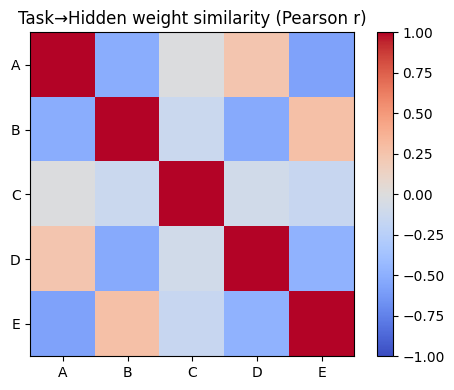

r(A,D) = 0.23778787352005928
r(B,E) = 0.2753867346257595
r(A,B) = -0.5101121045385693


In [5]:
import numpy as np, torch
import matplotlib.pyplot as plt
from prp.task_generator import generate_fixed_task_set

# --- 1) Map a task one-hot to its column index in W_th (row-major: in*N + out) ---
def task_onehot_to_col(task_vec, N_pathways=3):
    M = task_vec.reshape(N_pathways, N_pathways)   # NOTE: no transpose
    i_in, i_out = np.argwhere(M == 1)[0]
    return int(i_in * N_pathways + i_out)

# Pull one canonical one-hot for A..E from the generator
inp, task_onehots, _, meta = generate_fixed_task_set(seed=42)
labels = ['A','B','C','D','E']
cols   = {
    lab: task_onehot_to_col(
        task_onehots[np.where(meta["task_indices"] == lab)[0][0]]
    )
    for lab in labels
}

# --- 2) Get task→hidden weights (H x 9) ---
W_th = wrapper.model.fc_task_hidden.weight.detach().cpu().numpy()  # shape: (H, 9)

# Select the 5 columns corresponding to A..E (in that order)
W_sel = W_th[:, [cols[L] for L in labels]]  # (H, 5)

# --- 3) Pearson correlation matrix across those 5 weight columns ---
# np.corrcoef expects variables in rows if rowvar=True; we have variables in columns,
# so set rowvar=False or transpose.
S = np.corrcoef(W_sel, rowvar=False)  # 5x5 Pearson r

# --- 4) Plot & print key pairs ---
plt.figure(figsize=(5,4))
plt.imshow(S, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(5), labels); plt.yticks(range(5), labels)
plt.title("Task→Hidden weight similarity (Pearson r)")
plt.tight_layout()
plt.show()

i = {lab: idx for idx, lab in enumerate(labels)}
print("r(A,D) =", float(S[i['A'], i['D']]))
print("r(B,E) =", float(S[i['B'], i['E']]))
print("r(A,B) =", float(S[i['A'], i['B']]))


In [5]:
from prp.task_generator import generate_fixed_task_set

def _check_generator(N_pathways=3, N_features=3, samples_per_task=5000, sd_scale=0.25, seed=0):
    import numpy as np
    inp, task, tgt, _ = generate_fixed_task_set(
        N_pathways=N_pathways, N_features=N_features,
        samples_per_task=samples_per_task, sd_scale=sd_scale, seed=seed
    )

    # decode task (i,o) from 1-hot cue
    def decode_task(t):
        T = N_pathways**2
        M = t.reshape(T)[None, :]  # flat 1-hot
        M = t.reshape(N_pathways, N_pathways).T
        i, o = np.argwhere(M == 1)[0]
        return i, o

    # expected output given (x, i→o)
    def correct_out(x, i, o):
        out = np.zeros_like(x)
        Nf = N_features
        active = np.argmax(x[i*Nf:(i+1)*Nf])
        out[o*Nf + active] = 1
        return out

    # mapping correctness on the *binary* masks (no noise)
    # regenerate the same set without noise to check exactness
    x_mask = (_["input_masks"]["A"].shape[1])  # forces traceback if meta missing
    # sample a small slice for speed
    mismatches = 0
    sample_ix = np.random.choice(len(inp), size=1000, replace=False)
    for k in sample_ix:
        t = task[k]
        i, o = decode_task(t)
        # rebuild a *clean* binary stimulus with the same active features
        x = np.zeros_like(inp[k])
        for p in range(N_pathways):
            Nf = N_features
            active = np.argmax(inp[k][p*Nf:(p+1)*Nf])
            x[p*Nf + active] = 1
        y_hat = correct_out(x, i, o)
        if not np.array_equal(y_hat, tgt[k]):
            mismatches += 1
            break

    assert mismatches == 0, "Target mismatch for (stim, task) → target mapping!"
    print("✅ Mapping check passed, 0 mismatches on sample.")

    # balance check
    from collections import Counter
    def key(t): 
        M = t.reshape(N_pathways, N_pathways).T
        i,o = np.argwhere(M==1)[0]
        return (i,o)
    cnt = Counter([key(t) for t in task])
    print("Task counts:", cnt)
    print("✅ Generator sanity checks complete.")
    
_check_generator()


AssertionError: Target mismatch for (stim, task) → target mapping!

In [9]:
import numpy as np, torch
W = wrapper.model.fc_task_hidden.weight.detach().cpu().numpy()  # (H, 9)
s = np.linalg.svd(W, compute_uv=False)
print("Singular values:", s)
print("Explained variance by first component:", (s[0]**2)/(s**2).sum())


Singular values: [12.70424     2.475164    1.602195    0.27346605  0.06602747  0.06434913
  0.05892879  0.05424168  0.04827173]
Explained variance by first component: 0.94837624
